In [1]:
import networkx as nx
import osmnx as ox
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString

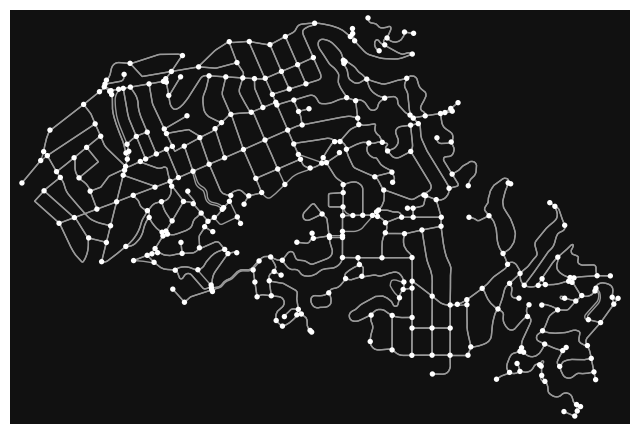

In [2]:
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

In [3]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
gdf_edges = gdf_edges.sort_index()

In [4]:
gdf_edges_simple = gpd.GeoDataFrame(columns=list(gdf_edges.columns) + ['u','v','key'])
gdf_edges_simple = gdf_edges_simple.set_index(['u','v','key']) 
# gdf_edges_simple.loc[(53017091, 53064327, 0)] = {'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': np.False_, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': LineString([(-122.248, 37.826), (-122.248, 37.826), (-122.246, 37.828)]), 'lanes': np.nan, 'maxspeed': np.nan, 'bridge': np.nan, 'junction': np.nan}
# list(gdf_edges_simple.index)

In [15]:
for u,v,_ in list(gdf_edges.index):
    # remove self-edges
    if(u==v):
        continue

    # keep only unique edges
    if((u,v,0) in list(gdf_edges_simple.index)):
        continue
        
    edges = gdf_edges.loc[(u,v)]
    if(edges.shape[0] == 1):
        gdf_edges_simple.loc[(u,v,0)] = edges.iloc[0]
    else: 
        gdf_edges_simple.loc[(u,v,0)] = edges.sort_values(by='length').iloc[-1]
    

In [16]:
G2 = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges_simple, graph_attrs=G.graph)
M = ox.convert.to_undirected(G2)

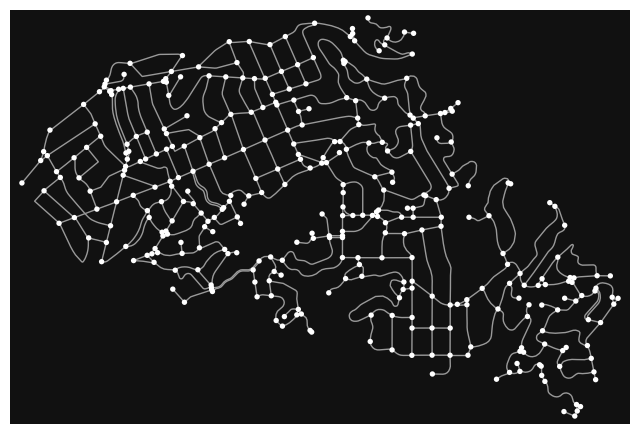

In [17]:
fig, ax = ox.plot.plot_graph(M)

In [27]:
n=len(M.nodes)
L = nx.laplacian_matrix(M, weight='length').toarray()

In [28]:
orig = ox.distance.nearest_nodes(G, X=-122.245846, Y=37.828903)
idx = list(G.nodes).index(orig)

In [29]:
p0 = np.zeros(n)
p0[idx]=1

In [46]:
d = [d for _, d in G.degree(weight='length')]
D = np.diag(d)
A = nx.adjacency_matrix(G).toarray()

In [47]:
W = np.eye(n)- 0.5*(np.eye(n) - A @ np.linalg.inv(D))

In [50]:
pi= d/(np.ones(n).T @ d) # stable distribution